In [1]:
#Import libraries 
import pandas as pd
import numpy as np
import requests
import matplotlib as plt
import seaborn as sns
import matplotlib.pyplot as plt


import requests
from bs4 import BeautifulSoup
import pandas as pd
from io import StringIO
import re
import random

import warnings
from pandas.errors import SettingWithCopyWarning
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=SettingWithCopyWarning)

### import main dataframes

In [2]:
build_stat= pd.read_csv('../output_data/all_build_base_stats.csv')
#reset index
build_stat= build_stat.set_index('Unnamed: 0', drop=True)
build_stat = build_stat.rename_axis('character_build', axis='index')
build_stat.head(3)

,ancestry,class,level,strength,dexterity,constitution,intelligence,wisdom,charisma
character_build,,,,,,,,,
dwarf barbarian strength,dwarf,barbarian strength,1,2.0,1.0,2.0,1.0,2.0,0.0
dwarf fighter strength,dwarf,fighter strength,1,2.0,1.0,2.0,1.0,2.0,0.0
dwarf fighter dexterity,dwarf,fighter dexterity,1,1.0,2.0,2.0,1.0,2.0,0.0


In [3]:
build_skill= pd.read_csv('../output_data/all_build_base_skills.csv')
#reset index
build_skill= build_skill.set_index('Unnamed: 0', drop=True)
build_skill = build_skill.rename_axis('character_build', axis='index')
build_skill.head(3)

,ancestry,class,level,hit points,speed,perception,fortitude,reflex,will,armor class,...,medium,heavy,unarmed,simple,martial,advanced,other,magical tradition,spell attack,spell dc
character_build,,,,,,,,,,,,,,,,,,,,,
dwarf barbarian strength,dwarf,barbarian strength,1,24.0,20.0,6.0,6.0,3.0,6.0,13.0,...,2.0,0.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,10.0
dwarf fighter strength,dwarf,fighter strength,1,22.0,20.0,6.0,6.0,5.0,4.0,13.0,...,2.0,2.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,10.0
dwarf fighter dexterity,dwarf,fighter dexterity,1,22.0,20.0,6.0,6.0,6.0,4.0,13.0,...,2.0,2.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,10.0


In [4]:
melee_attack_list= pd.read_csv('../output_data/melee_attack_output_all-builds.csv')

#clean up dataframe 
melee_attack_list= melee_attack_list.set_index('build', drop=True)
melee_attack_list= melee_attack_list.drop(columns=['Unnamed: 0'])

#adda  column for if it is a first or second action 
melee_attack_list['action_number']= [x.split(' ')[-1] for x in melee_attack_list['action']]

#view dataframe
melee_attack_list.head(3)

,level,action,attack_roll_result,attack modifier,penalties,dmg_dice,damage_type,damage_output,target_ac,crit_ac,action_number
build,,,,,,,,,,,
dwarf barbarian strength,1,str 1d4 melee attack 1,random_roll,4.0,0,4,melee,2.0,13.0,23.0,1
dwarf barbarian strength,1,str 1d4 melee attack 2,random_roll,4.0,5,4,melee,2.0,13.0,23.0,2
dwarf barbarian strength,1,str 1d6 melee attack 1,random_roll,4.0,0,6,melee,2.0,13.0,23.0,1


-----------

## Simulate the average/total damage per round for each character build
for EACH BUILD, simulate a round of combat by picking 2 actions from the action list, and using random number generators to estimate the outcome of those actions. Then three battle-performance metrics will be calucated from multi-round encounter simulation, and these metrics will be sampled by running over 100 encounters ("bootstraping" strategy)

### Three battle-performance metrics:
1) damage output (total and average)
3) rate of attack success
4) rate of crit attacks

In [8]:
def calculate_two_action_attack_output(action_list, target_ac):
    #substitute the action list to be used
    first_action = action_list
    
    #Randomly pick action from action list using a random number generator 
    random_action_num= random.randrange(0, len(first_action))
    
    #pull out that action information 
    first_attack = first_action.iloc[random_action_num]

    #FIRST -> make an attack roll against a target with the SAME AC 
    d20_roll= random.randrange(1, 21)
    attack_roll = d20_roll + first_attack['attack modifier'] - first_attack['penalties']
    
    #check if the attack roll hits based on the target ac
    if attack_roll >= target_ac:
        attack_sucess_status= 1
        attack_crit_status = 0
        #Calculate damage
        #roll random damage dice 
        dmg_dice_roll= random.randrange(1, first_attack['dmg_dice'])
        #add damage proficiencies 
        total_damage= dmg_dice_roll + first_attack['damage_output']
    elif d20_roll == 20: #critical attack is if d20 rolls a 20 OR if the attack roll is more than 20 above AC level 
        attack_crit_status= 1
        attack_sucess_status= 1
        #calculate double damage 
    
        dmg_dice_roll_1= random.randrange(1, first_attack['dmg_dice'])
        roll_1= dmg_dice_roll_1 + first_attack['damage_output']
        dmg_dice_roll_2= random.randrange(1, first_attack['dmg_dice'])
        roll_2= dmg_dice_roll_2 + first_attack['damage_output']
        total_damage= roll_1 + roll_2

    elif attack_roll >= (target_ac + 10): #critical attack is if d20 rolls a 20 OR if the attack roll is more than 20 above AC level 
        attack_crit_status= 1
        attack_sucess_status= 1
        #calculate double damage 
    
        dmg_dice_roll_1= random.randrange(1, first_attack['dmg_dice'])
        roll_1= dmg_dice_roll_1 + first_attack['damage_output']
        dmg_dice_roll_2= random.randrange(1, first_attack['dmg_dice'])
        roll_2= dmg_dice_roll_2 + first_attack['damage_output']
        total_damage= roll_1 + roll_2
    else:
        attack_sucess_status= 0 
        attack_crit_status = 0
        #record no damage 
        total_damage= 0 

    return attack_sucess_status, attack_crit_status, total_damage

def encounter_simulation(build_name, target_ac, total_num_round= 5, simulation_repeat= 20):
    #filter action list for only actions from a specific character build 
    build_action_list= melee_attack_list.loc[build_name]
    #organize into first and second action options
    first_action= build_action_list[build_action_list['action_number'] == '1']
    second_action= build_action_list[build_action_list['action_number'] == '2']

    #create output for simulation results
    simulation_outcome=pd.DataFrame(columns=['attack_sucess_1', 
                                             'attack_sucess_2', 
                                             'total_dmg', 
                                             'avg_dmg', 
                                             'attack_crit_status_1', 
                                             'attack_crit_status_2'])
    for simulation in range (simulation_repeat):
        count = simulation
        encounter_outcome=[]
        for round in range(total_num_round):
            attack_roll_1, attack_crit_1, total_damage_1 = calculate_two_action_attack_output(first_action, target_ac)
            attack_roll_2, attack_crit_2, total_damage_2 = calculate_two_action_attack_output(second_action, target_ac)
            total_round_damage= total_damage_1 + total_damage_2
        
            #save outcome to a list/dataframe 
            round_result= [round, attack_roll_1, attack_roll_2, attack_crit_1, attack_crit_2, total_round_damage]
            encounter_outcome.append(round_result)
    
        #Summarize the total 10-round encounter into a dataframe 
        encounter_result=pd.DataFrame(encounter_outcome, columns=['round', 
                                                                  'action_1_outcome', 
                                                                  'action_2_outcome', 
                                                                  'attack_1_crit', 
                                                                  'attack_2_crit', 
                                                                  'total_damage'])
        
        #calculate ecounter summary stats 
        attack_1_sucess= encounter_result['action_1_outcome'].mean()
        attack_2_sucess= encounter_result['action_2_outcome'].mean()
        crit_1_sucess= encounter_result['attack_1_crit'].mean()
        crit_2_sucess= encounter_result['attack_2_crit'].mean()
        total_dmg_output = encounter_result['total_damage'].sum()
        avg_dmg_output= encounter_result['total_damage'].mean()
        
        #save this as the final dataframe after 100 simulations 
        simulation_outcome.loc[f'{count}'] = [attack_1_sucess, attack_2_sucess, total_dmg_output, avg_dmg_output, crit_1_sucess, crit_2_sucess]

    #view final simulation outcome dataframe 
    return simulation_outcome

### Run the encounter simulation for ALL class combinations across MULTIPLE monster target AC values to get final battle metrics across low-mid level monster ac targets

In [17]:
#make a default spreadsheet to save all simulation results for all build
result_column_list= ['attack_sucess_1', 
                     'attack_sucess_2', 
                     'total_dmg', 
                     'avg_dmg', 
                     'attack_crit_status_1', 
                     'attack_crit_status_2', 
                     'build_name', 
                     'build_level', 
                     'target_ac', 
                     'encounter_num']
all_build_sim_results= pd.DataFrame( columns = result_column_list)

#filter out all character build option for a specific class 
chosen_class_list= build_skill['class'].unique()

for class_filter in chosen_class_list: 
    class_category_forbuild= class_filter
    #create a histogram overlapping based on each ancestry/ character build combination 
    group_by_class = build_skill[build_skill['class'] == class_category_forbuild]
    build_combo_for_class = group_by_class.index.to_list()

    #create first round where target_ac is the same as the build's ac
    same_ac_as_build = melee_attack_list.loc[build_combo_for_class[0]]['target_ac'][0]
    target_ac_for_attack = same_ac_as_build

    #loop simulation to run from all class combinations
    for char_build in build_combo_for_class:
        build_name= char_build
        #loop for a range of target AC to save summary results 
        for monster_ac in range (10, 30):
            target_ac_for_attack= monster_ac
            output_result= encounter_simulation(build_name, target_ac_for_attack)
            build_ancestry= build_name.replace(class_category_forbuild, '')
            
            #add relevant information to simulation file 
            output_result['build_name'] = build_name
            output_result['build_level'] = 1
            output_result['target_ac']= target_ac_for_attack
            output_result['encounter_num']= output_result.index
    
            #add simulation results to master spreadsheet
            all_build_sim_results = pd.concat([all_build_sim_results, output_result])

#view final dataframe 
print("number of 5-round encounters estimated: ", len(all_build_sim_results))


### add aditional filter columns for visualizing 
all_build_sim_results['ancestry'] = [x.split(" ")[0] for x in all_build_sim_results['build_name']]
all_build_sim_results['class_build']= [x.split(" ")[-2] for x in all_build_sim_results['build_name']]

####save final spreadsheet in output data file 
all_build_sim_results.to_csv('../output_data/simualtion_results_ac10-30.csv')

#view sample of results
all_build_sim_results.sample(10)

number of 5-round encounters estimated:  14000


,attack_sucess_1,attack_sucess_2,total_dmg,avg_dmg,attack_crit_status_1,attack_crit_status_2,build_name,build_level,target_ac,encounter_num,ancestry,class_build
15,0.0,0.0,0.0,0.0,0.0,0.0,human-dex fighter strength,1,21,15,human-dex,fighter
11,0.6,0.2,16.0,3.2,0.0,0.0,human-dex barbarian strength,1,10,11,human-dex,barbarian
5,0.2,0.0,4.0,0.8,0.0,0.0,orc-dex barbarian strength,1,22,5,orc-dex,barbarian
14,0.2,0.2,28.0,5.6,0.0,0.0,elf fighter dexterity,1,19,14,elf,
16,1.0,0.8,49.0,9.8,0.0,0.0,human-dex rogue dexterity,1,11,16,human-dex,rogue
13,0.0,0.0,0.0,0.0,0.0,0.0,human-str rogue dexterity,1,27,13,human-str,rogue
17,0.2,0.0,3.0,0.6,0.0,0.0,halfling barbarian strength,1,24,17,halfling,barbarian
6,0.2,0.4,36.0,7.2,0.0,0.4,human-dex fighter dexterity,1,22,6,human-dex,
5,0.4,0.2,21.0,4.2,0.0,0.0,human-dex rogue dexterity,1,18,5,human-dex,rogue
4,0.2,0.0,8.0,1.6,0.2,0.0,orc-dex fighter strength,1,27,4,orc-dex,fighter


----

### Next steps: create a summary visual for average and distribtuion of the total simulation, so all builds are summarized on the same plot

### visual goal: boxplot to show the distribution of each battle metric 
#### x value = target_ac, y value = battle metric, color/hue/organization = build_name?

##### visual: facet grid for each build?

,attack_sucess_1,attack_sucess_2,total_dmg,avg_dmg,attack_crit_status_1,attack_crit_status_2,build_name,build_level,target_ac,encounter_num,ancestry,class_build
11,0.4,0.2,21.0,4.2,0.0,0.0,orc-dex rogue dexterity,1,15,11,orc-dex,rogue
4,0.6,0.0,14.0,2.8,0.0,0.0,elf sorcerer charisma,1,19,4,elf,sorcerer
16,0.2,0.2,26.0,5.2,0.2,0.2,human-dex fighter dexterity,1,27,16,human-dex,


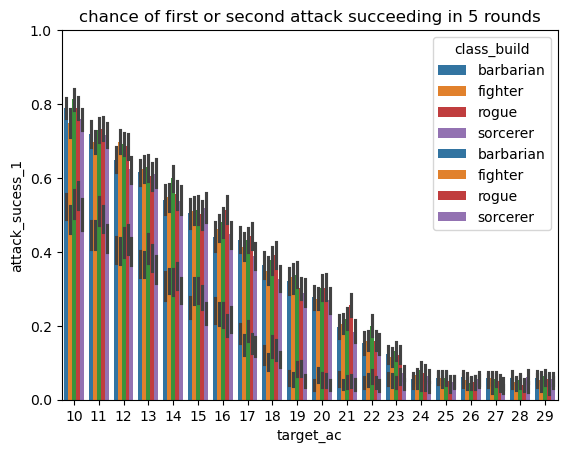

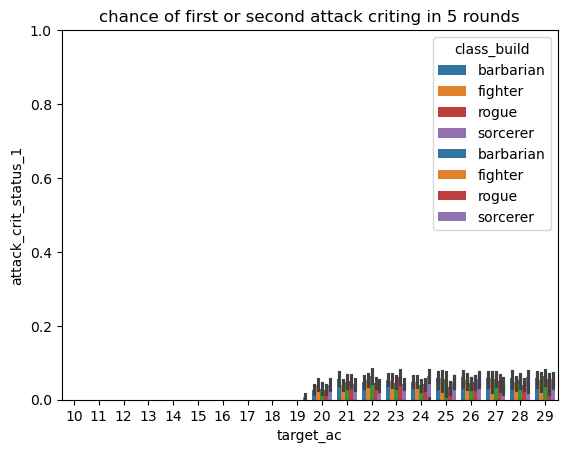

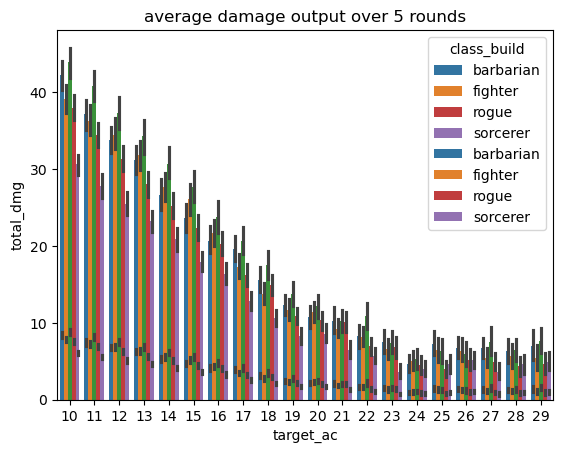

In [12]:
all_build_sim_results.head(2)
len(all_build_sim_results['build_name'].unique())


### add aditional filter columns for visualizing 
all_build_sim_results['ancestry'] = [x.split(" ")[0] for x in all_build_sim_results['build_name']]
all_build_sim_results['class_build']= [x.split(" ")[-2] for x in all_build_sim_results['build_name']]

#visualize the boxplot for the first metric-> attack_sucess_1
fig, ax= plt.subplots()
plt.ylim(0, 1)
ax= sns.barplot(data= all_build_sim_results, x="target_ac", y="attack_sucess_1", hue="class_build")
ax = sns.barplot(data= all_build_sim_results, x="target_ac", y="attack_sucess_2", hue="class_build")
plt.title("chance of first or second attack succeeding in 5 rounds")

#visualize the boxplot for the second metric-> probability of crit
fig, ax= plt.subplots()
plt.ylim(0, 1)
ax= sns.barplot(data= all_build_sim_results, x="target_ac", y="attack_crit_status_1", hue="class_build")
ax = sns.barplot(data= all_build_sim_results, x="target_ac", y="attack_crit_status_2", hue="class_build")
plt.title("chance of first or second attack criting in 5 rounds")

#visualize the boxplot for the second metric-> probability of crit
fig, ax= plt.subplots()
ax= sns.barplot(data= all_build_sim_results, x="target_ac", y="total_dmg", hue="class_build")
ax = sns.barplot(data= all_build_sim_results, x="target_ac", y="avg_dmg", hue="class_build")
plt.title("average damage output over 5 rounds")


all_build_sim_results.sample(3)

### create a facet grid where each class gets a graph in a row, and within each of that graph the ancestry types are distributed

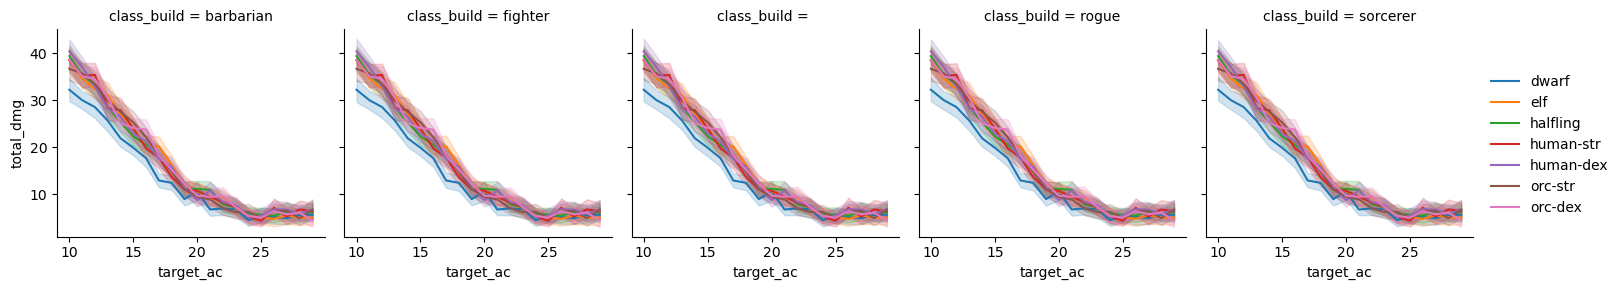

In [21]:
fgrid_fig = sns.FacetGrid(all_build_sim_results, col="class_build")
fgrid_fig.map(sns.lineplot, x="target_ac", y="total_dmg", hue="ancestry", data=all_build_sim_results);
fgrid_fig.add_legend()

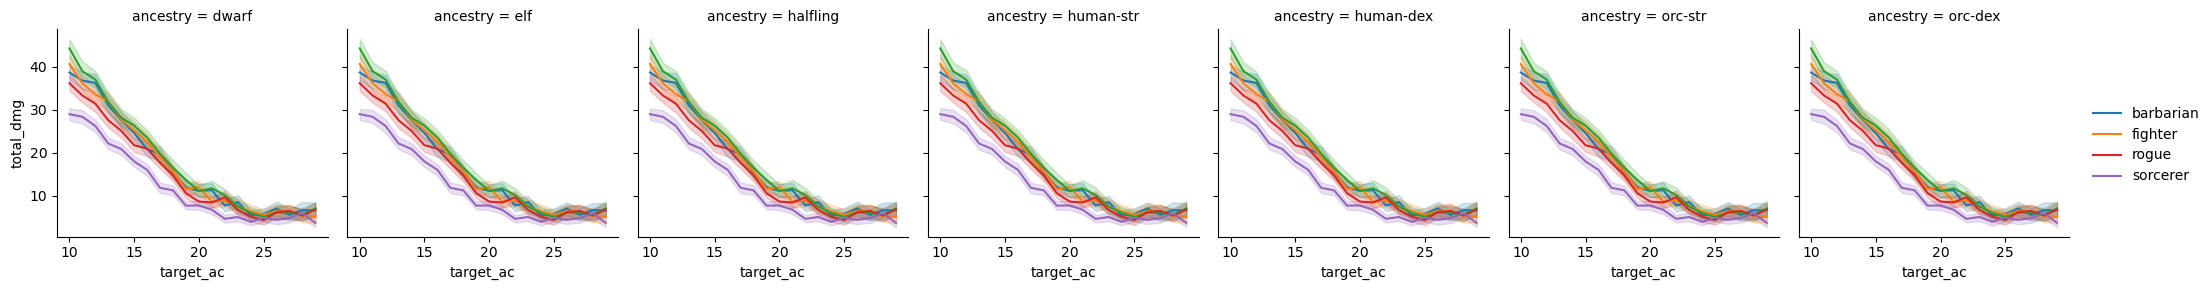

In [22]:
fgrid_fig = sns.FacetGrid(all_build_sim_results, col="ancestry")
fgrid_fig.map(sns.lineplot, x="target_ac", y="total_dmg", hue="class_build", data=all_build_sim_results);
fgrid_fig.add_legend()

In [2]:
ancestry_list_options= all_build_sim_results['ancestry'].unique().tolist()
print(ancestry_list_options[2])
filter_graph = all_build_sim_results[all_build_sim_results['ancestry'] == ancestry_list_options[2]]
sns.lineplot(x="target_ac", y="total_dmg", hue="class_build", data=filter_graph)

NameError: name 'all_build_sim_results' is not defined

#### SO --> treating this as a "standard curve" for the target ac performance levels for each moster
* How does each monster (based on AC) perform compared to the expected curve?
* How does the monster 'last' (damage output) through 5 rounds?
* IF the monster is defeated in LESS than the standard curve (5 rounds ) => "easy" encounter
* IF the monster is NOT defeated in the standard curve (more than 5 rounds) => "hard" encounter
* IF the monster falls along the standard curve (defeated in 5 rounds) => "moderate" encounter

* How does each monster fair between classes? Is there monsters that are more or less 'vulnerable' to specific classes?